## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [5]:
!wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

--2026-03-29 17:48:14--  https://thome.isir.upmc.fr/classes/RITAL/input.txt
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  1.62MB/s    in 0.7s    

2026-03-29 17:48:16 (1.62 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [6]:
! pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 9.6 MB/s eta 0:00:00


In [7]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)

file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [ ]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len -1)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1,len(string)).long()
    for c in range(len(string)):
        tensor[0,c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks],dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks],dim=0)

    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [9]:
import torch.nn.functional as f

class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1,rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(self.n_char,self.hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = nn.RNN(self.hidden_size,self.hidden_size,self.n_layers)

        #(batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(self.hidden_size,self.output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output,_  = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input,hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.rnn(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden


## Text generation function

Sample text from the model

In [10]:
def generate(model,prime_str='A', predict_len=100, temperature=0.8):
    prime_input = char_tensor(prime_str).squeeze(0)
    hidden = None
    predicted = prime_str+""
    # Use priming string to "build up" hidden state

    for p in range(len(prime_str)-1):
        _,hidden = model.forward_seq(prime_input[p].unsqueeze(0),hidden)

    #print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
                # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        #print(output_dist)
        top_i = torch.multinomial(output_dist, 1)[0]
        #print(top_i)
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat([prime_input,char_tensor(predicted_char).squeeze(0)])

    return predicted



## Training loop for net

In [11]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers) #create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    #compute loss
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))

    #compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()



for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


 4s (100 0%) 3.0486]
WhisotSeasr, tI aseomousor: t heN nna'ded t

 u  urhetihrirr tg se  seonthh tia shrued nle l toi, heh
 

 8s (200 1%) 2.8218]
Whe whawan,Tharup.Thheosd b wes   waubyw l s u de niipldinkh thhh.

 r n ;O,U

E
LAthihit naldoaucU
 c 

 12s (300 1%) 2.7739]
Whis hetand
ITheronoc mer,

KPherthut hind KER on,
Wrl ud ud sn nn by fe thiurl maupg al kn dsund amin 

 17s (400 2%) 2.6520]
Wheneindoghe s ter inthotodll wertesotheth wamomy therocore t thot her be bothitee yse dth h wovelthat 

 21s (500 2%) 2.6134]
Wh he fd ants por a wees poorcot d INEThear,


EE: dined y teme red dy nand th se ant
Gorarour tothe n 

 24s (600 3%) 2.5507]
Wheran ond me s arothe wousafaire bere ak t chmevathesan oforou f esatheacin sthl ped -tathe atyot hen 

 29s (700 3%) 2.5976]
Whe f pu f lauro tit, burom leme mabthes methe ty i be INCicedions sren:
SAnculanordor bhy co s s the  

 33s (800 4%) 2.5142]
Who k tes th s hdene thend d, as, thoukr ar'thesatheth I t  POsour.
HAve os f me, t, ange, 

## Visualize loss

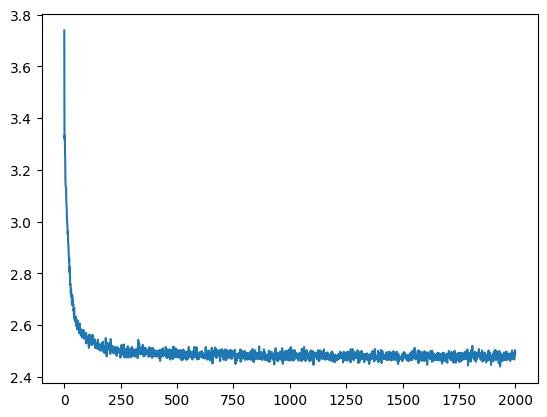

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [13]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

Th dathait.
I y,
I't ive, h n keecot pin; ecin.
Hedweis ps yll t n rs RDIZAs'let cte miothes I: batorco ak d d sean, 's thoreer D wan is ashioongrowende s toutoyoncowid t sh
It gmo dy s.
MNou t;

Marel
----
Thy.
Fpe tou sp, mereno wr, me char ouche o nougimy, hase wian:




F ot' y m

Fan be
we w
Or mer unie f d on s l thyor o heinous.
NCouglinst t n mases t sthe mou sthathe d me won atoreand d ots bll t y
----
The wou wouses ales pe anouthe o wis t s he be and the there tho my thathan willy s le s r I in d be I:

Fod ino bl y and te t s I:
F be t the thand ber t cof s and h ar my de t the on hin whathakn as b
----
There me wind s the winous s s the y s the s the me n s thy s wind win t me whe the te he my wous the t ar the me ous s t thare s s me an s y whe the the s thind y there the ine wis the che we wind thes
----
The me the t the me the the the the t the s the the the the be t the the the the s the the s the the the the s the the the the s s t the the s the me s the the the the s

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


In [14]:
class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1, rnn_cell=nn.RNN):
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        self.embed = nn.Embedding(self.n_char, self.hidden_size)

        # utiliser rnn_cell au lieu de nn.RNN en dur
        self.rnn = rnn_cell(self.hidden_size, self.hidden_size, self.n_layers, batch_first=True)

        self.predict = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input):
        input = self.embed(input)
        output, _ = self.rnn(input)
        output = self.predict(torch.tanh(output))
        return output

    def forward_seq(self, input, hidden=None):
        input = self.embed(input)
        output, hidden = self.rnn(input, hidden)
        output = self.predict(torch.tanh(output))
        return output, hidden

In [15]:
model2 = RNN(n_characters, hidden_size, n_characters, n_layers, rnn_cell=nn.GRU)
model3 = RNN(n_characters, hidden_size, n_characters, n_layers, rnn_cell=nn.LSTM)

model_optimizer2 = torch.optim.Adam(model2.parameters(), lr=lr)
model_optimizer3 = torch.optim.Adam(model3.parameters(), lr=lr)

In [16]:
def train(model, optimizer, inp, target):
    optimizer.zero_grad()
    output = model(inp)
    loss = criterion(output.view(-1, output.size(-1)), target.view(-1))
    loss.backward()
    optimizer.step()

    return loss.item()

In [17]:
min_chunk_len = 20
max_chunk_len = 100

def get_chunk_len(epoch, n_epochs):
    return min_chunk_len + (max_chunk_len - min_chunk_len) * epoch // n_epochs

In [19]:
start = time.time()
all_losses2 = []
all_losses3 = []
loss_avg2 = 0
loss_avg3 = 0

for epoch in range(1, n_epochs + 1):
    current_chunk_len = get_chunk_len(epoch, n_epochs)

    inp, target = random_training_set(current_chunk_len, batch_size)

    loss2 = train(model2, model_optimizer2, inp, target)
    loss3 = train(model3, model_optimizer3, inp, target)

    loss_avg2 += loss2
    loss_avg3 += loss3

    if epoch % print_every == 0:
        print('[%s (%d %d%%)] chunk_len=%d' % (
            time_since(start), epoch, epoch / n_epochs * 100, current_chunk_len
        ))
        print('GRU  loss = %.4f' % loss2)
        print(generate(model2, 'Wh', 100), '\n')

        print('LSTM loss = %.4f' % loss3)
        print(generate(model3, 'Wh', 100), '\n')

    if epoch % plot_every == 0:
        all_losses2.append(loss_avg2 / plot_every)
        all_losses3.append(loss_avg3 / plot_every)
        loss_avg2 = 0
        loss_avg3 = 0

 8s (100 0%)] chunk_len=20
GRU  loss = 2.3725
What id en tapes Pot shelng worlos sane,
Whte he ya mut, the thy wosee hey ethe heaee eget the an-ungi 

LSTM loss = 2.3466
Whhe cas and pan there
Anper voeaod theret meint wharl,
Fot I of gaunI thest be sore word te the fike  

 15s (200 1%)] chunk_len=20
GRU  loss = 2.3722
Whe thor miurt unlomolly gut whe, of rto thirt sanre,
fik me buln! I crilge gace an a wout fot musuril 

LSTM loss = 2.3943
Whhe mi bat, bere in the the u the toloile i coel ti tire thilid the theid the andqost oy geamins hen  

 23s (300 1%)] chunk_len=21
GRU  loss = 2.3058
Wht come shaus tore, thiu whaltenges he wim
fe afe, you; and,
 he, fot,
Hene at hirdepte chrushe as py 

LSTM loss = 2.2669
Whaur the I dots, boweln nimht me dineore woth por bey ot amce the greke so'id wile thole'er, sin weu  

 32s (400 2%)] chunk_len=21
GRU  loss = 2.2745
Whadteud sour os, nour there the as, as ce wouaser dyo this houn. ind unames:
Ingish thim and as an me 

LSTM loss = 2.2384
Wh

KeyboardInterrupt: 

In [20]:
# partie 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = model2.to(device)
model3 = model3.to(device)

model_optimizer2 = torch.optim.Adam(model2.parameters(), lr=lr)
model_optimizer3 = torch.optim.Adam(model3.parameters(), lr=lr)


def generate(model, prime_str='Wh', predict_len=100, temperature=0.8):
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        inp = char_tensor(prime_str).to(device)
        predicted = prime_str
        hidden = None

        for _ in range(predict_len):
            output, hidden = model.forward_seq(inp, hidden)
            output = output[:, -1, :]


            output_dist = output.view(-1).div(temperature).exp()
            top_i = torch.multinomial(output_dist, 1)[0].item()
            predicted += all_characters[top_i]

            inp = torch.tensor([[top_i]], dtype=torch.long, device=device)

    model.train()
    return predicted

def train(model, optimizer, inp, target):
    inp = inp.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    output = model(inp)
    loss = criterion(output.view(-1, output.size(-1)), target.view(-1))
    loss.backward()
    optimizer.step()
    return loss.item()


start = time.time()
all_losses2 = []
all_losses3 = []
loss_avg2 = 0
loss_avg3 = 0

for epoch in range(1, n_epochs + 1):
    current_chunk_len = get_chunk_len(epoch, n_epochs)

    inp, target = random_training_set(current_chunk_len, batch_size)

    loss2 = train(model2, model_optimizer2, inp, target)
    loss3 = train(model3, model_optimizer3, inp, target)

    loss_avg2 += loss2
    loss_avg3 += loss3

    if epoch % print_every == 0:
        print('[%s (%d %d%%)] chunk_len=%d' % (
            time_since(start), epoch, epoch / n_epochs * 100, current_chunk_len
        ))
        print('GRU  loss = %.4f' % loss2)
        print(generate(model2, 'Wh', 100), '\n')

        print('LSTM loss = %.4f' % loss3)
        print(generate(model3, 'Wh', 100), '\n')

    if epoch % plot_every == 0:
        all_losses2.append(loss_avg2 / plot_every)
        all_losses3.append(loss_avg3 / plot_every)
        loss_avg2 = 0
        loss_avg3 = 0

 1s (100 0%)] chunk_len=20
GRU  loss = 2.3051
Whilne.

GONIUS:
I witserierst, me the co lore ir hagn,
So shout liy mire fordn?

POMEFIE:
What faree  

LSTM loss = 2.1651
Whaze us the will made
And and name thee of teold inter and the sorder that under that feedings in of  

 3s (200 1%)] chunk_len=20
GRU  loss = 2.0643
Who sour by he he wots not this maglout good face wege,,
The's meell the heart of lors mowtred sird th 

LSTM loss = 1.9315
What by decicions, afse in the was
The thou tome and be the you lide are the for sens a buche, the par 

 4s (300 1%)] chunk_len=21
GRU  loss = 2.2043
Whece.

SARUNCARLE:
Ky, helicess wess, cilles the, werilane?

RRONN:
Peveeloves, a theat hens, batespl 

LSTM loss = 2.0270
When all sa all was? E'ce of it sees, and oe of't, it westaefoll in wall, hower of the mite dowart lea 

 6s (400 2%)] chunk_len=21
GRU  loss = 2.1622
Whed that of hath hould the to morlal arle hath.

SANIULIO:
In, is palleghernter that shemft more whis 

LSTM loss = 2.0450
Whoy 

KeyboardInterrupt: 